In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict


from eelbrain import NDVar, UTS, Sensor, Case, Var, Factor, Dataset, save, plot, boosting

from ridge_regression_functions import (
    load_all_trials,
    split_trials_by_condition,
    WIN_OFFSET1,
    WIN_OFFSET2,
)

# 10 ms sampling → 100 Hz
SAMPLE_RATE = 100.0
TSTEP = 1.0 / SAMPLE_RATE  # 0.01 s

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']


In [9]:
from eelbrain import load

path_dec = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\TRF\dec_eeg_to_ppd_sub-042_l13.pickle"

dec_42_l13 = load.unpickle(path_dec)


0.09351855884105721
<NDVar 'eeg': 17 sensor, 649 time>
None


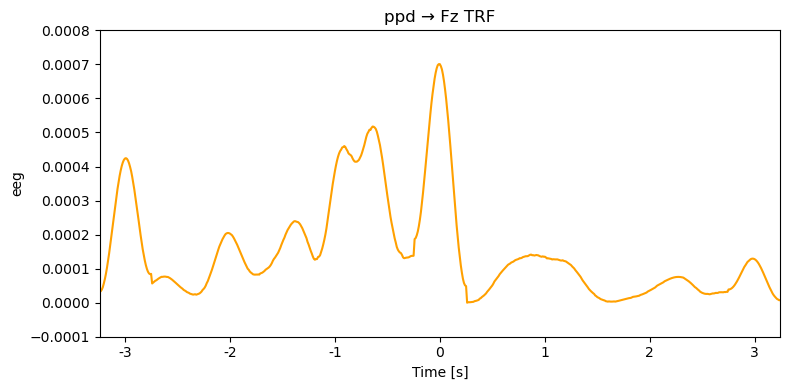

In [10]:
# decoding performance (scalar r, because y was ppd)
print(dec_42_l13.r)

# decoder kernel (time × sensor or sensor × time, depending on version)
h_dec = dec_42_l13.h_scaled
print(h_dec)
# e.g. TRF for Fz
h_Fz_dec = h_dec.sub(sensor='Fz')
plot.UTS(h_Fz_dec, axtitle="ppd → Fz TRF")

# predicted pupil (case × time)
ppd_pred = dec_42_l13.y_pred
print(ppd_pred)


In [11]:
lags_peak = {}
for ch in FRONTAL_MIDLINE:
    h_ch = h_dec.sub(sensor=ch)
    t = h_ch.time.times
    y = h_ch.x
    i_peak = np.argmax(np.abs(y))
    lags_peak[ch] = t[i_peak] * 1000  # ms

print(lags_peak)


{'AFz': np.float64(-1120.0), 'AF3': np.float64(2990.0), 'AF4': np.float64(-2780.0000000000005), 'Fz': np.float64(-10.000000000000231), 'F1': np.float64(2590.0), 'F2': np.float64(-2100.0), 'F3': np.float64(1009.9999999999998), 'F4': np.float64(2990.0), 'FC3': np.float64(2990.0), 'FC1': np.float64(9.999999999999787), 'FC2': np.float64(589.9999999999999), 'FC4': np.float64(2990.0), 'Cz': np.float64(-3000.0), 'C3': np.float64(-3000.0), 'C1': np.float64(-3240.0), 'C2': np.float64(-3000.0), 'C4': np.float64(-3000.0)}


In [4]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from eelbrain import load


def analyze_all_decoders(
    trf_dir=r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran1\TRF"
):
    """
    Read all dec_eeg_to_ppd_sub-xxx_lyy.pickle decoders in `trf_dir`,
    extract correlation r and predictive power, and test whether r > 0.

    Returns
    -------
    df : pandas.DataFrame
        Columns: ['subject', 'load', 'r', 'var_explained']
    """
    trf_dir = Path(trf_dir)
    pattern = "dec_eeg_to_ppd_sub-*_l*.pickle"

    rows = []

    for fpath in trf_dir.glob(pattern):
        name = fpath.name
        # parse subject and load from filename: dec_eeg_to_ppd_sub-042_l13.pickle
        m = re.match(r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle", name)
        if not m:
            print(f"[skip] Could not parse subject/load from {name}")
            continue

        subj = int(m.group(1))
        load_val = int(m.group(2))

        # load BoostingResult
        dec = load.unpickle(fpath)

        # r: scalar (because y = ppd is 1D). Handle NDVar or float.
        try:
            r_val = float(dec.r)
        except Exception:
            r_val = float(np.asarray(dec.r.x).item())

        # predictive power: proportion_explained (0–1) → %
        var_exp = getattr(dec, "proportion_explained", None)
        if var_exp is not None:
            try:
                ve = float(var_exp) * 100.0
            except Exception:
                ve = float(np.asarray(var_exp.x).item()) * 100.0
        else:
            ve = np.nan

        rows.append({
            "subject": subj,
            "load": load_val,
            "r": r_val,
            "var_explained": ve,
            "file": name,
        })

    if not rows:
        print("No decoder files found; check TRF directory and naming.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    print("\nCollected decoder results:")
    print(df.sort_values(["subject", "load"]))

    # === Overall test: is mean r > 0 ? ===
    r_all = df["r"].values
    mean_r = r_all.mean()
    sd_r = r_all.std(ddof=1)
    n = len(r_all)

    # two-sided t-test vs 0, then convert to one-sided if mean_r > 0
    t_stat, p_two = ttest_1samp(r_all, popmean=0.0)
    if mean_r >= 0:
        p_one = p_two / 2.0
    else:
        p_one = 1.0 - p_two / 2.0  # if mean < 0, one-sided r > 0 is not interesting anyway

    var_explained_all = df["var_explained"].values
    mean_ve = var_explained_all.mean()
    sd_ve = var_explained_all.std(ddof=1)
    n_ve = len(var_explained_all)

    t_stat_ve, p_two_ve = ttest_1samp(var_explained_all, popmean=0.0)
    if mean_ve >= 0:
        p_one_ve = p_two_ve / 2.0
    else:
        p_one_ve = 1.0 - p_two_ve / 2.0

    print("\n=== Overall decoder r (EEG → ppd) ===")
    print(f"n = {n}")
    print(f"mean r = {mean_r:.4f}, SD = {sd_r:.4f}")
    print(f"t({n-1}) = {t_stat:.3f}, one-sided p (r>0) = {p_one:.3e}")

    # Also show overall predictive power
    if df["var_explained"].notna().any():
        mean_ve = df["var_explained"].mean()
        sd_ve = df["var_explained"].std(ddof=1)
        print(f"mean % variance explained = {mean_ve:.3f} ± {sd_ve:.3f}")
        print(f"t({n_ve-1}) = {t_stat_ve:.3f}, one-sided p (var explained > 0) = {p_one_ve:.3e}")

    # === Per-load tests ===
    print("\n=== Per-load tests (decoder r > 0) ===")
    for load_val in sorted(df["load"].unique()):
        sub_df = df[df["load"] == load_val]
        r_vals = sub_df["r"].values
        if len(r_vals) < 2:
            print(f"Load {load_val}: only {len(r_vals)} subject(s); skipping t-test.")
            continue
        mean_r_l = r_vals.mean()
        sd_r_l = r_vals.std(ddof=1)
        t_l, p2_l = ttest_1samp(r_vals, popmean=0.0)
        p1_l = p2_l / 2.0 if mean_r_l >= 0 else 1.0 - p2_l / 2.0
        print(f"  Load {load_val}: n = {len(r_vals)}, "
              f"mean r = {mean_r_l:.4f} ± {sd_r_l:.4f}, "
              f"t = {t_l:.3f}, one-sided p = {p1_l:.3e}")

    return df


In [5]:
trf_dir2=r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\TRF"
df_dec2 = analyze_all_decoders(trf_dir=trf_dir2)
num_below_zero = (df_dec2['r'] < 0).sum()
print(num_below_zero)



Collected decoder results:
    subject  load         r  var_explained                               file
0        33    13  0.037993      -0.710068  dec_eeg_to_ppd_sub-033_l13.pickle
1        34    13 -0.014333      -2.178793  dec_eeg_to_ppd_sub-034_l13.pickle
2        36    13 -0.106317      -5.710800  dec_eeg_to_ppd_sub-036_l13.pickle
3        38    13  0.097141      -0.829007  dec_eeg_to_ppd_sub-038_l13.pickle
4        39    13  0.219736       4.517171  dec_eeg_to_ppd_sub-039_l13.pickle
5        40    13  0.255995       6.215218  dec_eeg_to_ppd_sub-040_l13.pickle
6        41    13  0.241316       5.573940  dec_eeg_to_ppd_sub-041_l13.pickle
7        42    13  0.028670      -1.541695  dec_eeg_to_ppd_sub-042_l13.pickle
8        43    13  0.024272      -1.118609  dec_eeg_to_ppd_sub-043_l13.pickle
9        44    13  0.064389      -1.174189  dec_eeg_to_ppd_sub-044_l13.pickle
10       45    13  0.027904      -1.451955  dec_eeg_to_ppd_sub-045_l13.pickle
11       47    13  0.098147      -1.

In [2]:
trf_dir2=r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran06\TRF"
df_dec2 = analyze_all_decoders(trf_dir=trf_dir2)
num_below_zero = (df_dec2['r'] < 0).sum()
print(num_below_zero)



Collected decoder results:
    subject  load         r  var_explained                               file
0        33    13  0.078997       0.303114  dec_eeg_to_ppd_sub-033_l13.pickle
1        34    13  0.221329       3.543259  dec_eeg_to_ppd_sub-034_l13.pickle
2        36    13  0.184802       1.708509  dec_eeg_to_ppd_sub-036_l13.pickle
3        38    13 -0.041444      -0.654005  dec_eeg_to_ppd_sub-038_l13.pickle
4        39    13  0.271286       3.142377  dec_eeg_to_ppd_sub-039_l13.pickle
5        40    13  0.199411       2.594964  dec_eeg_to_ppd_sub-040_l13.pickle
6        41    13  0.023350      -0.044855  dec_eeg_to_ppd_sub-041_l13.pickle
7        42    13  0.085389       0.474204  dec_eeg_to_ppd_sub-042_l13.pickle
8        43    13  0.054185       0.033807  dec_eeg_to_ppd_sub-043_l13.pickle
9        44    13 -0.021203       0.022404  dec_eeg_to_ppd_sub-044_l13.pickle
10       45    13 -0.044523      -0.735745  dec_eeg_to_ppd_sub-045_l13.pickle
11       47    13  0.046602       0.

In [2]:
from pathlib import Path
import re
import numpy as np
import eelbrain
from matplotlib import pyplot as plt

TRF_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\TRF")

cases = []
for f in TRF_DIR.glob("dec_eeg_to_ppd_sub-*_l*.pickle"):
    m = re.match(r"dec_eeg_to_ppd_sub-(\d+)_l(\d+)\.pickle", f.name)
    if not m:
        continue
    subj = f"S{int(m.group(1)):03d}"
    load_val = int(m.group(2))

    dec = eelbrain.load.unpickle(f)

    trf = dec.h_scaled                     # NDVar(sensor × time): decoder weights
    r_val = float(dec.r)                   # scalar correlation
    ve = float(dec.proportion_explained) * 100  # % variance explained

    cases.append([subj, load_val, trf, r_val, ve])

dataset_dec = eelbrain.Dataset.from_caselist(
    ['subject', 'load', 'trf_dec', 'r', 'var_explained'],
    cases,
    random='subject'
)

print(f"Loaded {len(dataset_dec)} decoder results.")


Loaded 5 decoder results.


Decoder r: mean=0.1002, SD=0.1191, n=52


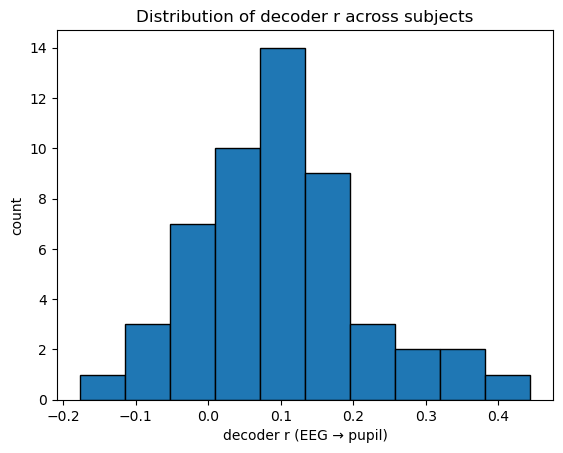

In [3]:
import numpy as np

rs = np.array(dataset_dec['r'])
print(f"Decoder r: mean={rs.mean():.4f}, SD={rs.std(ddof=1):.4f}, n={len(rs)}")

plt.figure()
plt.hist(rs, bins=10, edgecolor='black')
plt.xlabel("decoder r (EEG → pupil)")
plt.ylabel("count")
plt.title("Distribution of decoder r across subjects")
plt.show()


<Figure size 640x480 with 0 Axes>

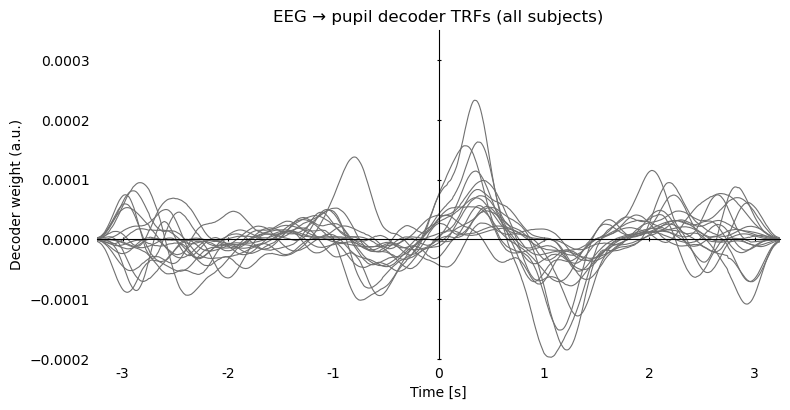

In [4]:
trf_all_dec = dataset_dec['trf_dec']  # NDVar(case × sensor × time)

plt.figure()
pb_dec = eelbrain.plot.Butterfly(
    trf_all_dec,
    vmin=-0.0002, vmax=0.00035,   # adjust to your scale if needed
    linewidth=0.8,
    color='#707070',
    frame='t',
    ylabel="Decoder weight (a.u.)",
    clip=True,
)
plt.title("EEG → pupil decoder TRFs (all subjects)") # one per sensor, averaged over subjects

plt.show()


<Figure size 640x480 with 0 Axes>

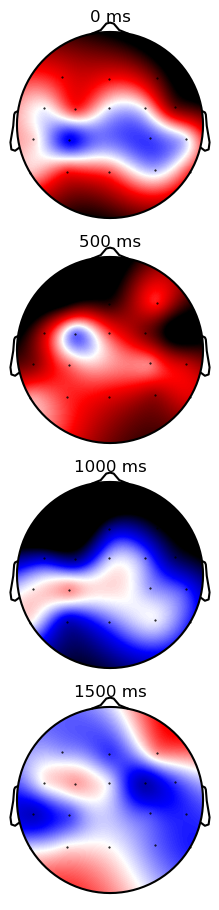

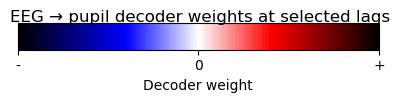

In [6]:
# mean over case dimension: sensor × time
trf_mean_dec = trf_all_dec.mean('case')

# choose times where you expect strong decoder weights
times_topo = [0, 0.5, 1.0, 1.5]  # seconds
labels_topo = [f"{int(t*1000)} ms" for t in times_topo]

# build list of sensor NDVars, one per time
slices = [trf_mean_dec.sub(time=t) for t in times_topo]

# one figure with 3 topomaps
plt.figure()
p_topo_dec = eelbrain.plot.Topomap(
    slices,
    axtitle=labels_topo,
    vmax=0.0001,          # same as butterfly vmin/vmax
    clip='circle',
)
p_topo_dec.plot_colorbar(
    label="Decoder weight",
    ticks={0.0001: '+', -0.0001: '-', 0: '0'}
)
plt.suptitle("EEG → pupil decoder weights at selected lags")
plt.show()


<Figure size 640x480 with 0 Axes>

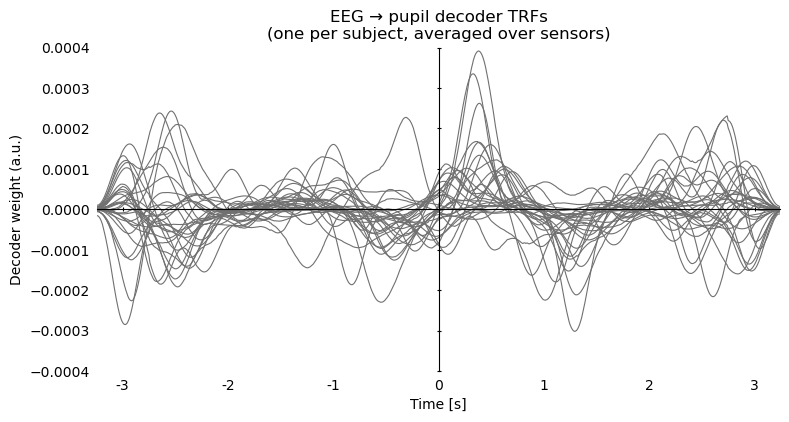

In [8]:
# ------------------------------------------------------------
# 1) TRF per subject (average over sensors)
# ------------------------------------------------------------
trf_subj = trf_all_dec.mean('sensor')  # NDVar: case × time

plt.figure()
pb_subj = eelbrain.plot.Butterfly(
    trf_subj,
    linewidth=0.8,
    color='#707070',
    frame='t',
    clip=True,
)
plt.title("EEG → pupil decoder TRFs\n(one per subject, averaged over sensors)")
plt.ylabel("Decoder weight (a.u.)")
plt.show()


C:\Users\cdd\AppData\Local\Temp\ipykernel_27764\3960827057.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

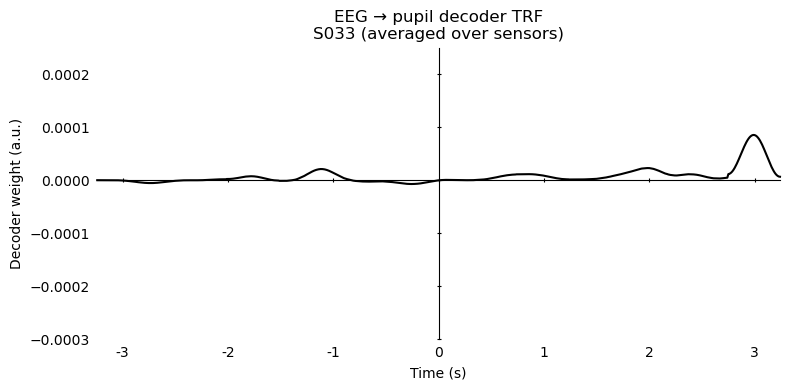

<Figure size 640x480 with 0 Axes>

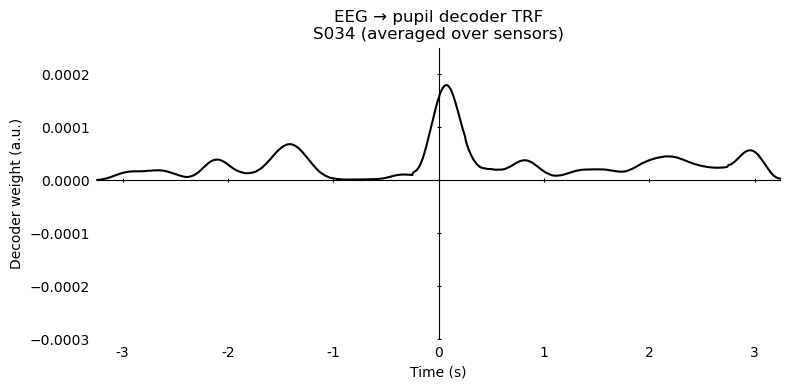

<Figure size 640x480 with 0 Axes>

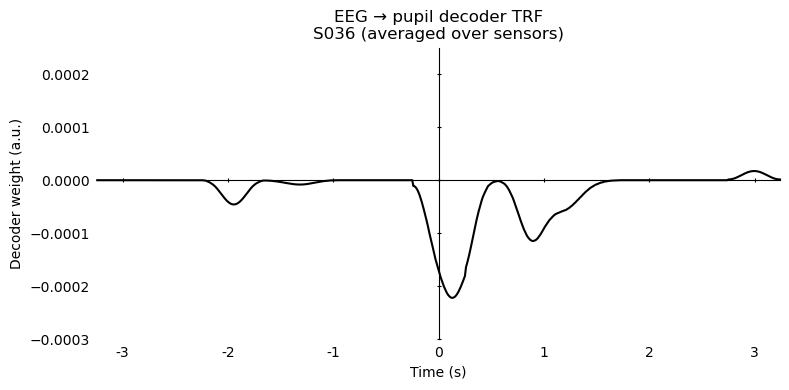

<Figure size 640x480 with 0 Axes>

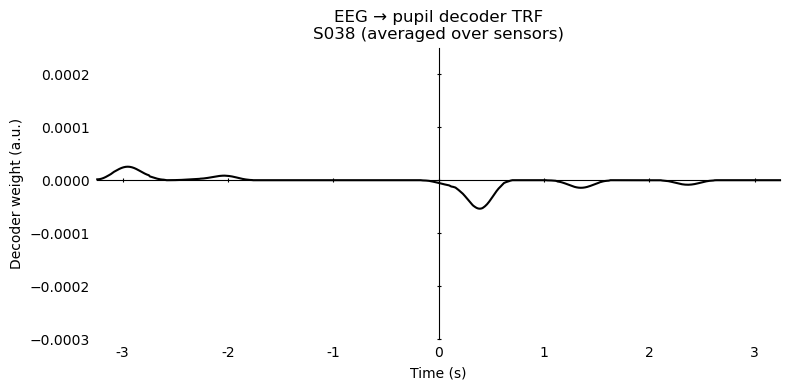

<Figure size 640x480 with 0 Axes>

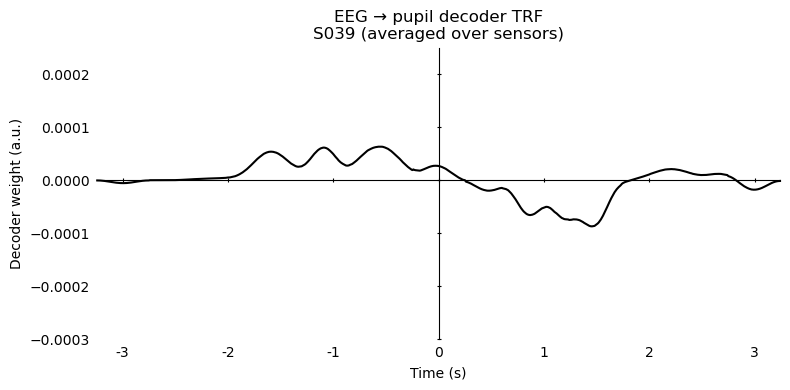

<Figure size 640x480 with 0 Axes>

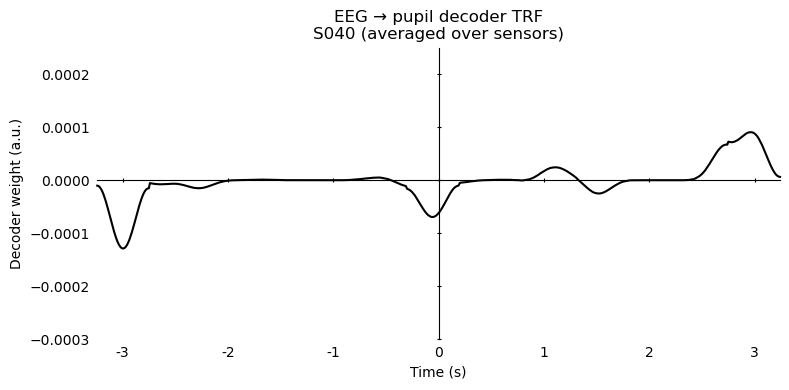

<Figure size 640x480 with 0 Axes>

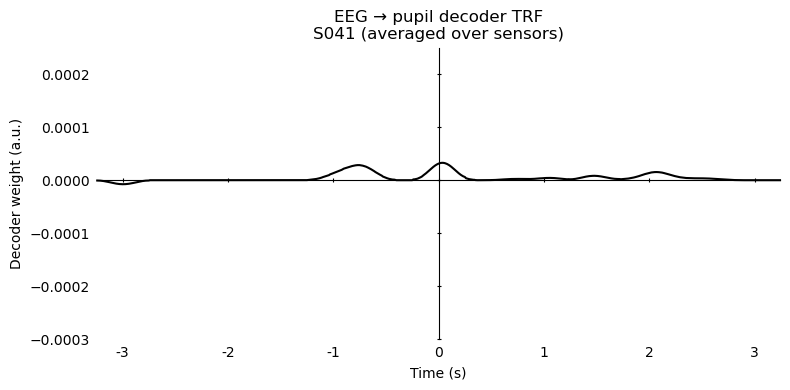

<Figure size 640x480 with 0 Axes>

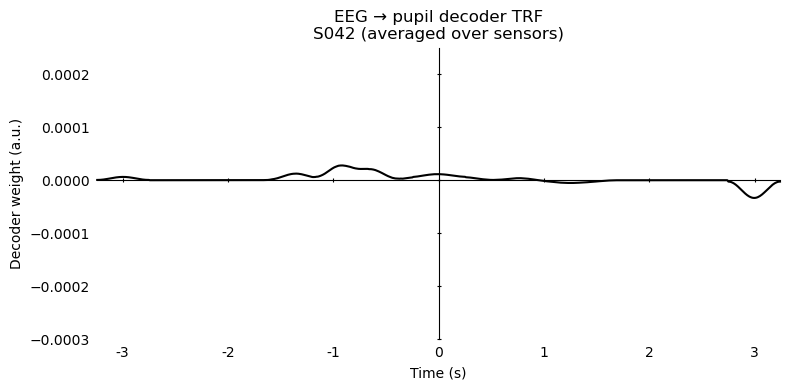

<Figure size 640x480 with 0 Axes>

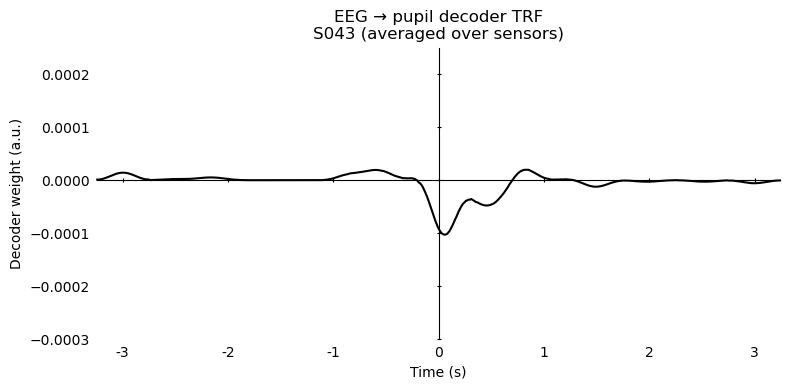

<Figure size 640x480 with 0 Axes>

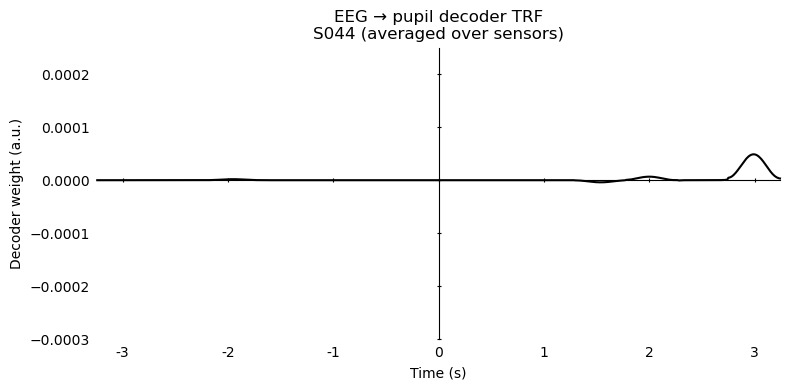

<Figure size 640x480 with 0 Axes>

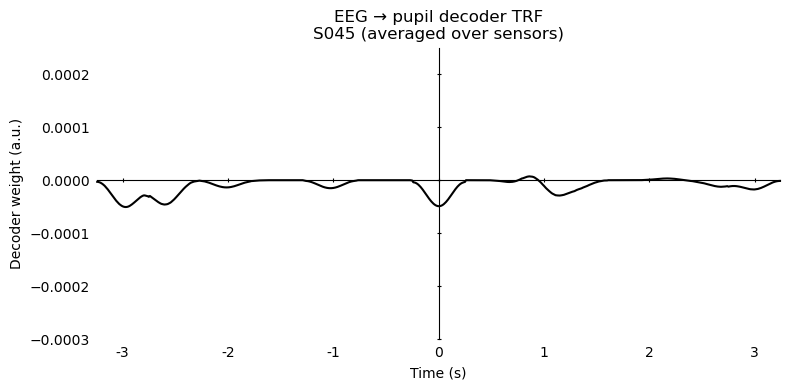

<Figure size 640x480 with 0 Axes>

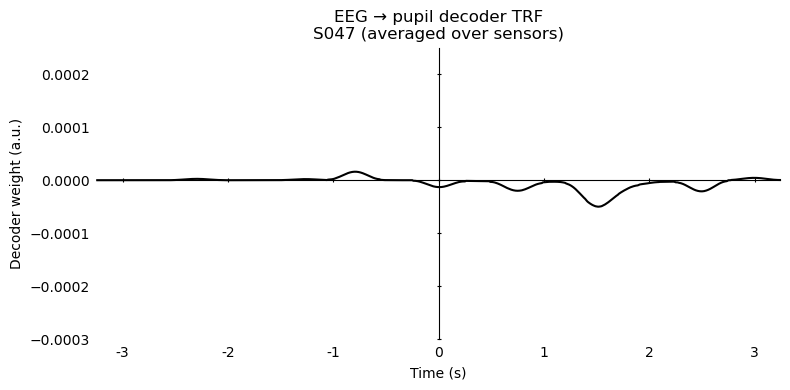

<Figure size 640x480 with 0 Axes>

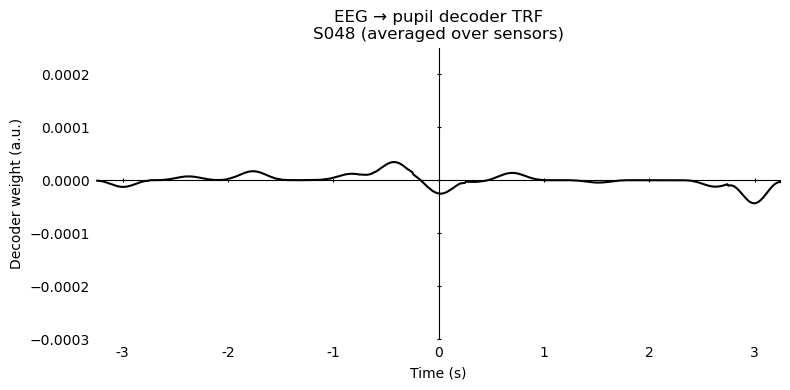

<Figure size 640x480 with 0 Axes>

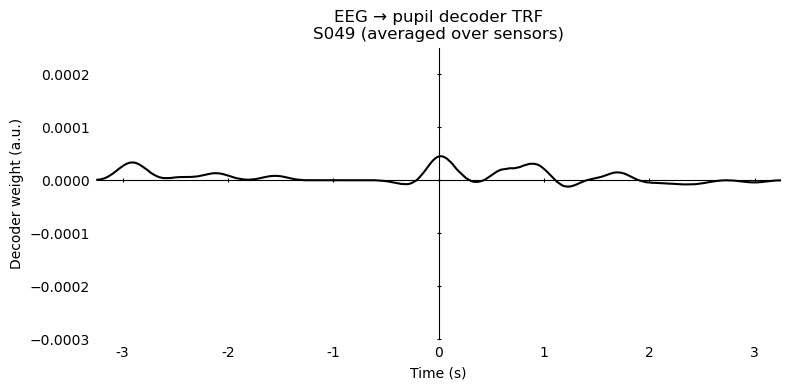

<Figure size 640x480 with 0 Axes>

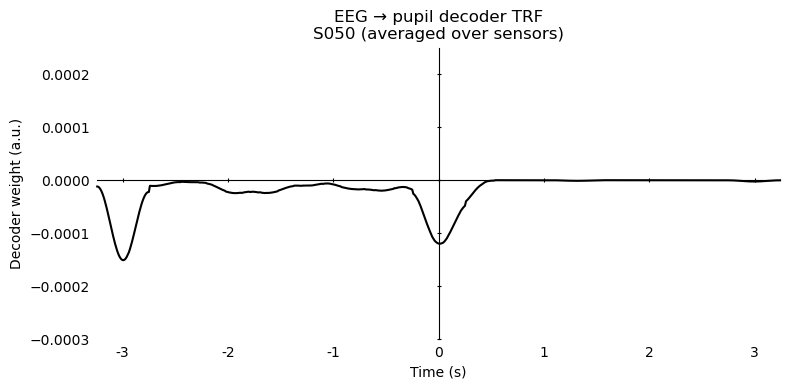

<Figure size 640x480 with 0 Axes>

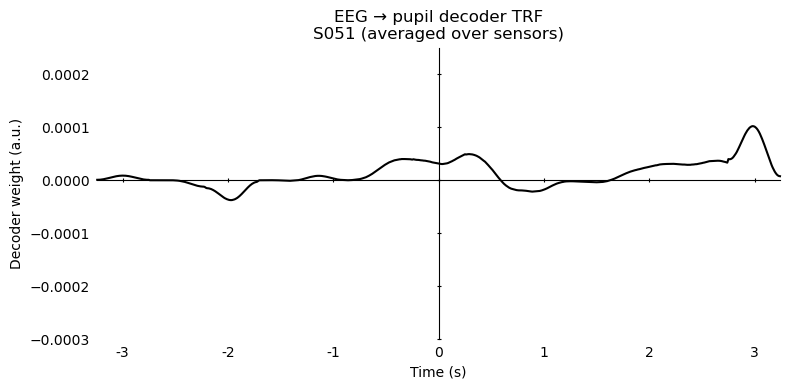

<Figure size 640x480 with 0 Axes>

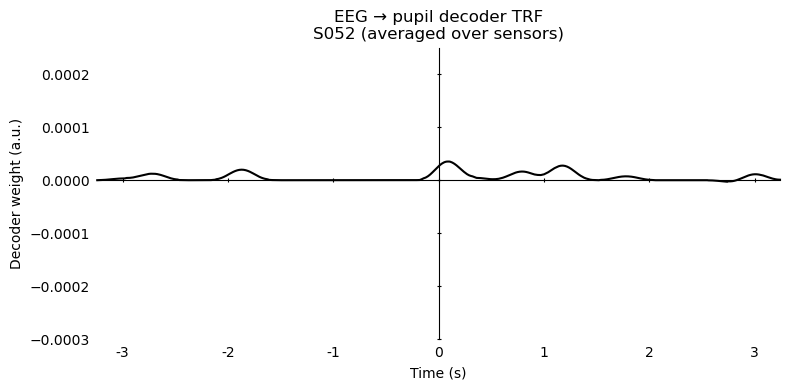

<Figure size 640x480 with 0 Axes>

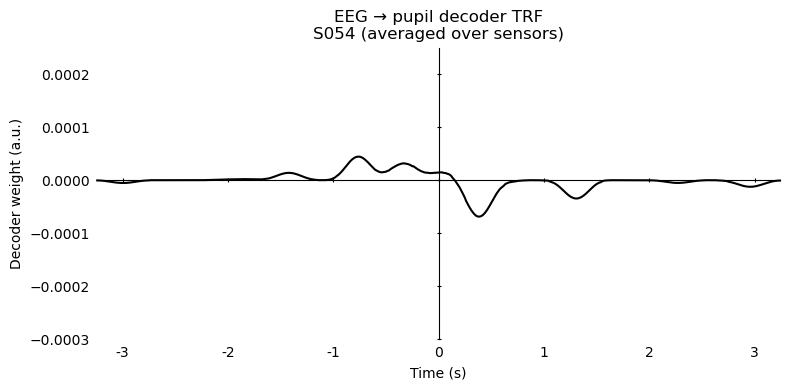

<Figure size 640x480 with 0 Axes>

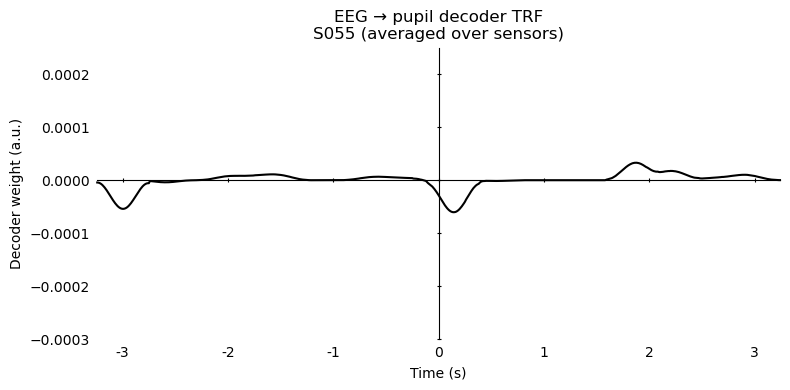

<Figure size 640x480 with 0 Axes>

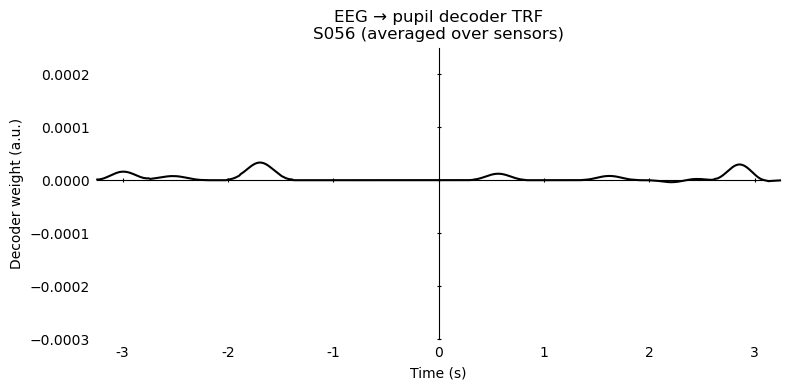

<Figure size 640x480 with 0 Axes>

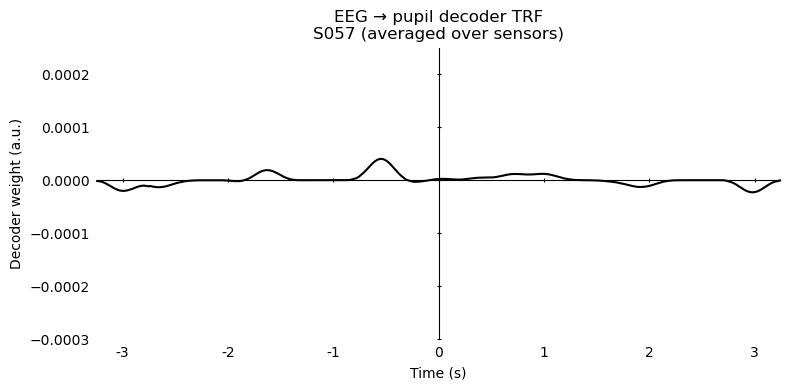

<Figure size 640x480 with 0 Axes>

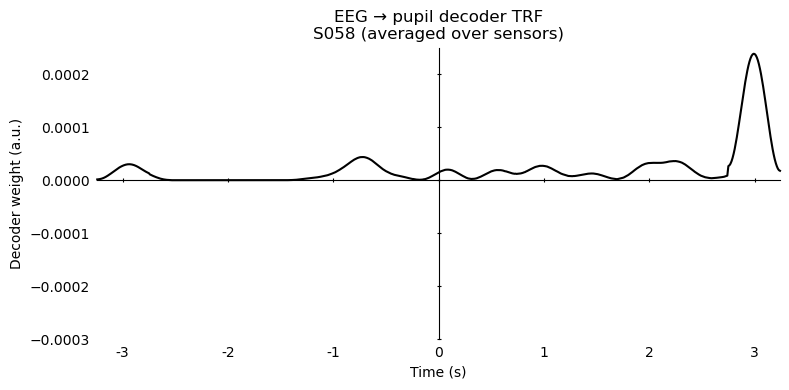

<Figure size 640x480 with 0 Axes>

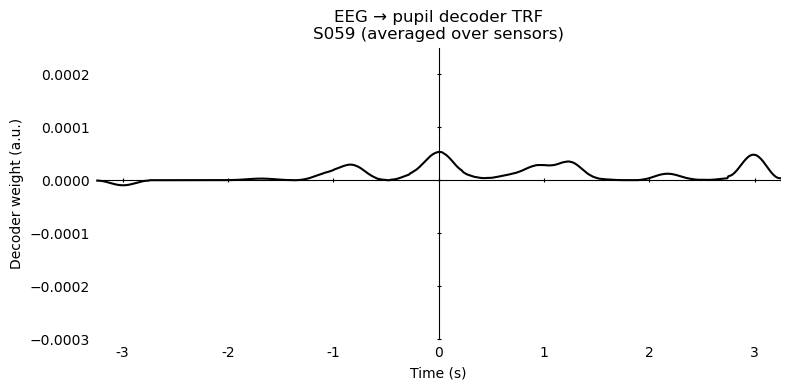

<Figure size 640x480 with 0 Axes>

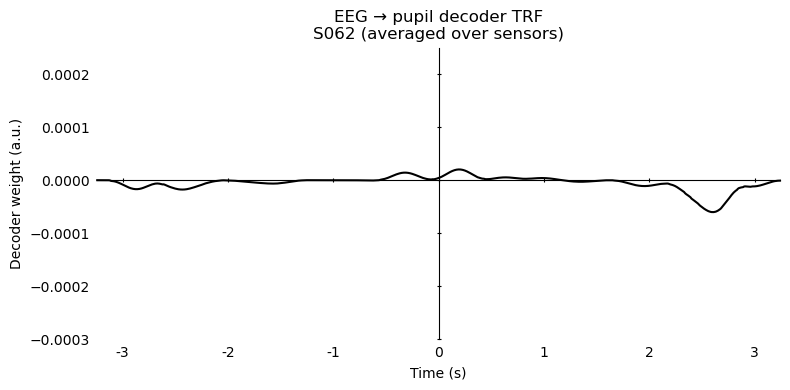

<Figure size 640x480 with 0 Axes>

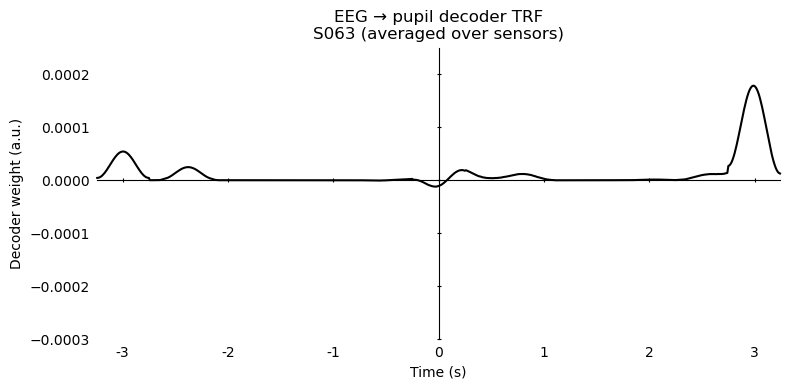

<Figure size 640x480 with 0 Axes>

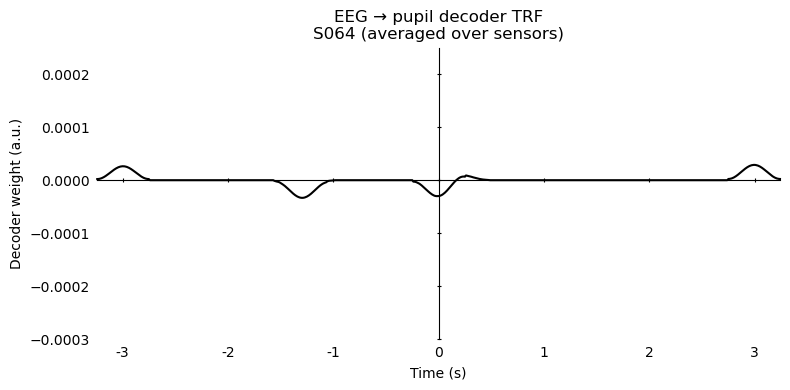

<Figure size 640x480 with 0 Axes>

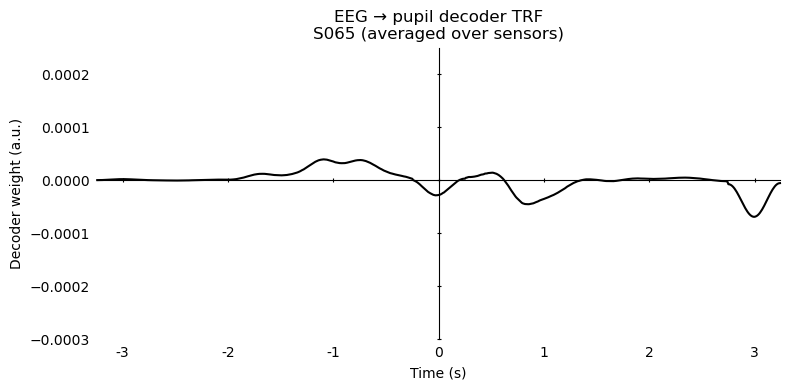

<Figure size 640x480 with 0 Axes>

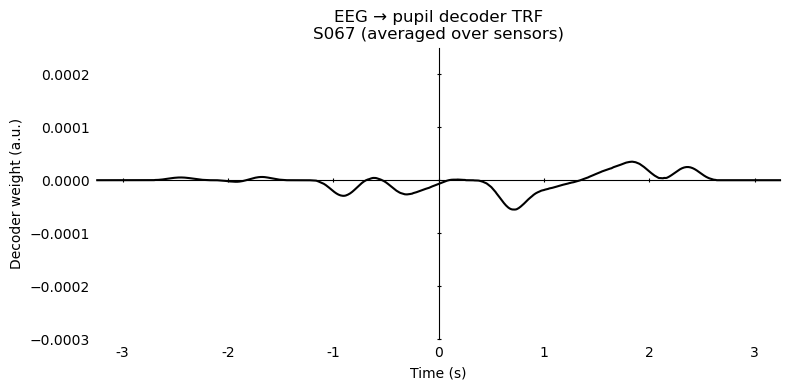

<Figure size 640x480 with 0 Axes>

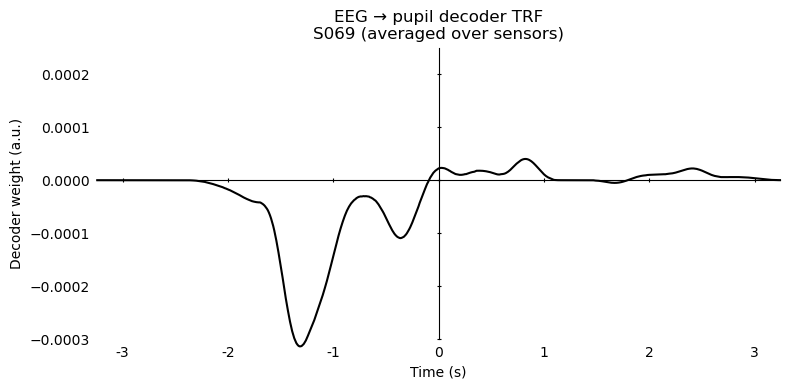

<Figure size 640x480 with 0 Axes>

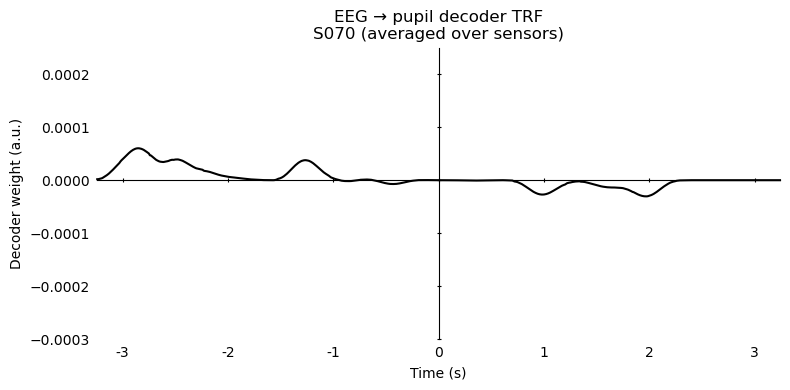

<Figure size 640x480 with 0 Axes>

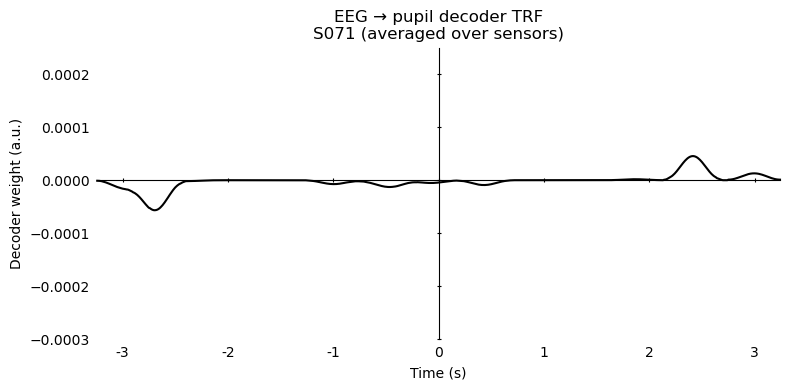

<Figure size 640x480 with 0 Axes>

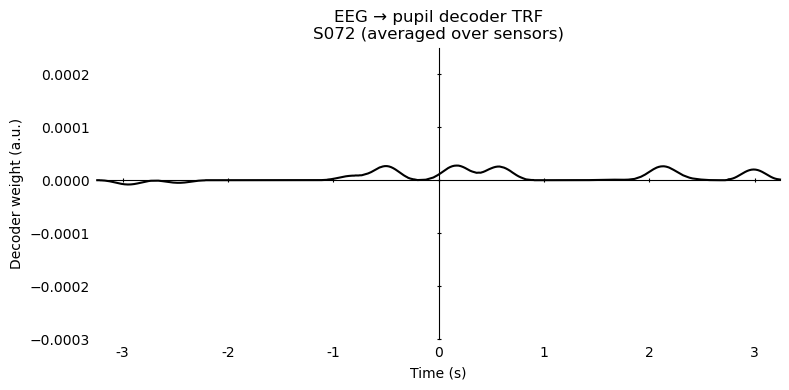

<Figure size 640x480 with 0 Axes>

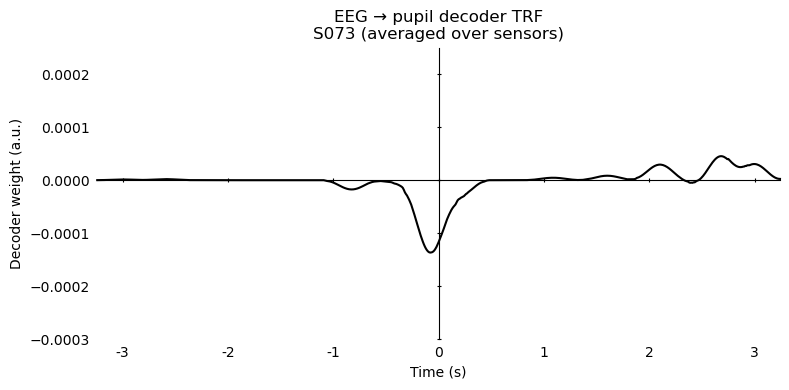

<Figure size 640x480 with 0 Axes>

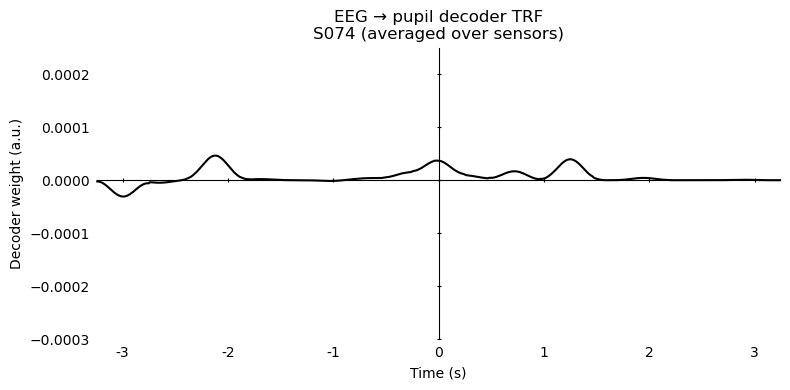

<Figure size 640x480 with 0 Axes>

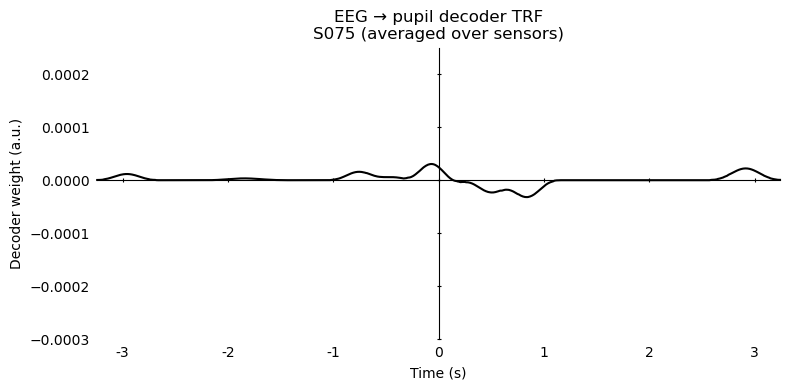

<Figure size 640x480 with 0 Axes>

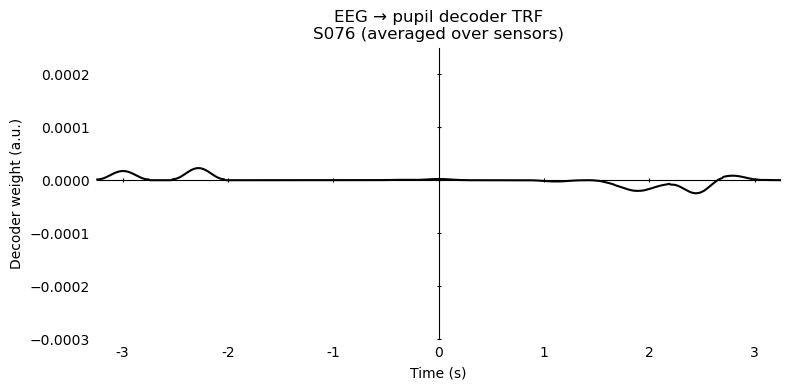

<Figure size 640x480 with 0 Axes>

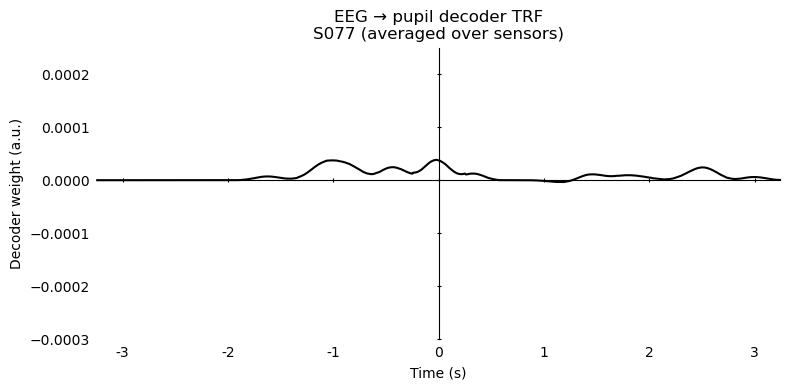

<Figure size 640x480 with 0 Axes>

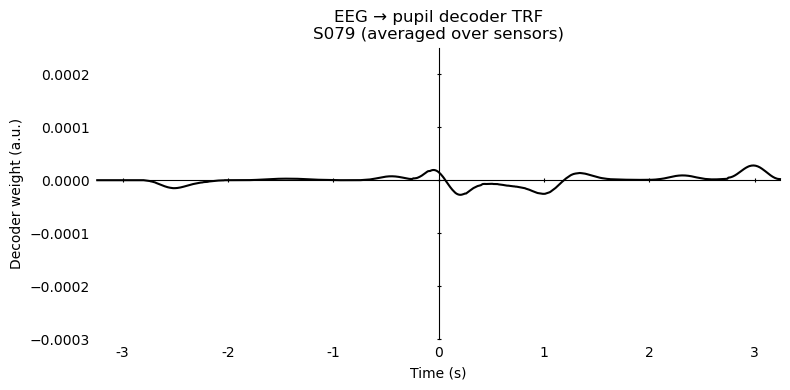

<Figure size 640x480 with 0 Axes>

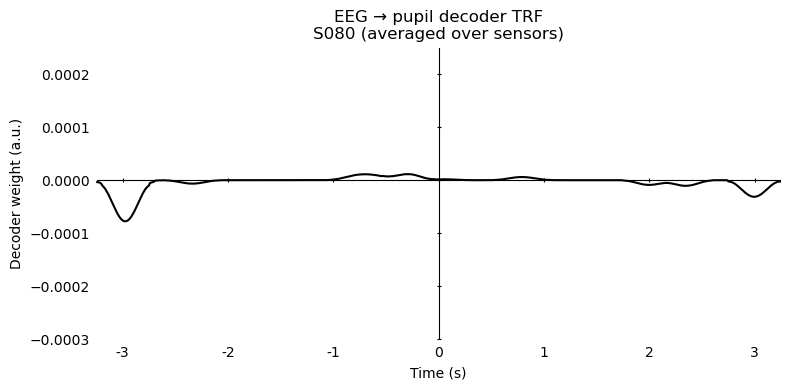

<Figure size 640x480 with 0 Axes>

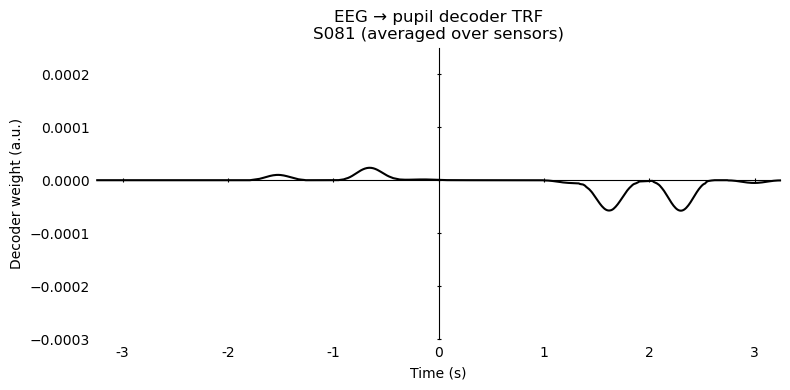

<Figure size 640x480 with 0 Axes>

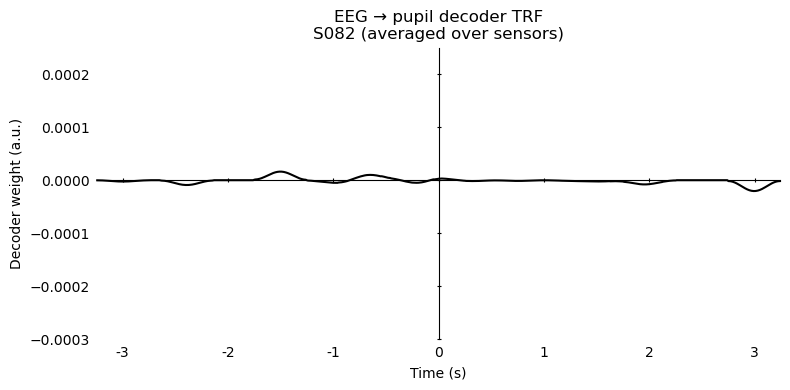

<Figure size 640x480 with 0 Axes>

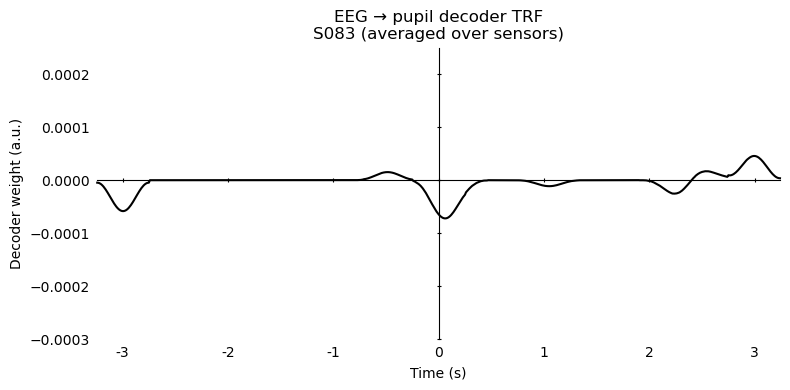

<Figure size 640x480 with 0 Axes>

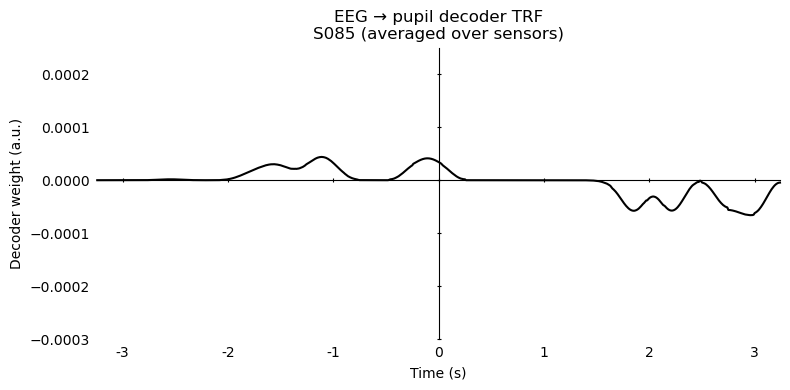

<Figure size 640x480 with 0 Axes>

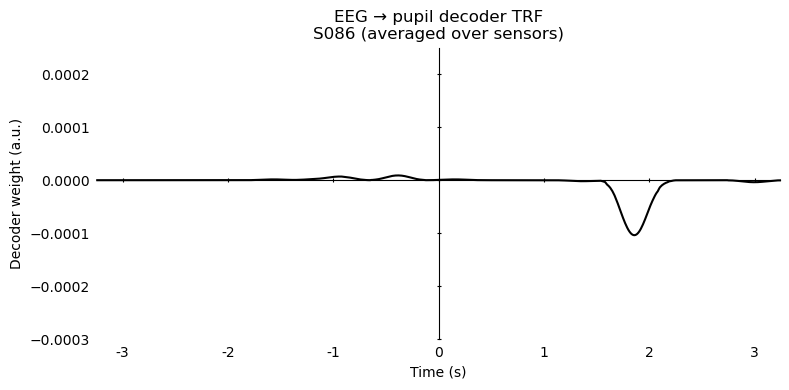

<Figure size 640x480 with 0 Axes>

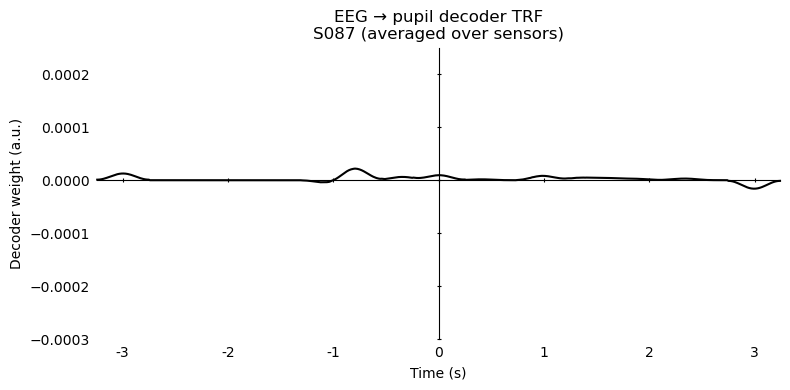

<Figure size 640x480 with 0 Axes>

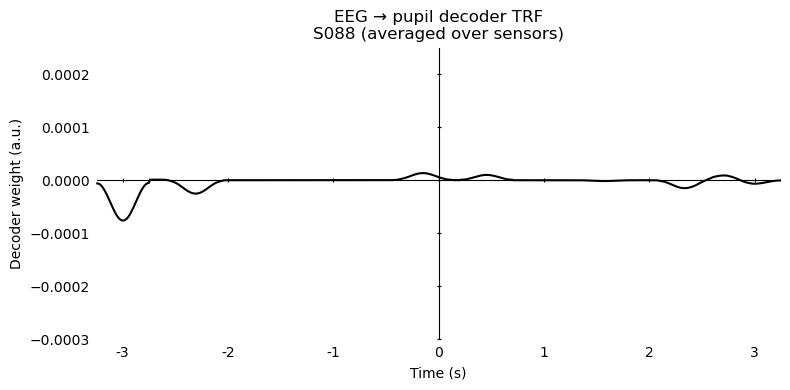

<Figure size 640x480 with 0 Axes>

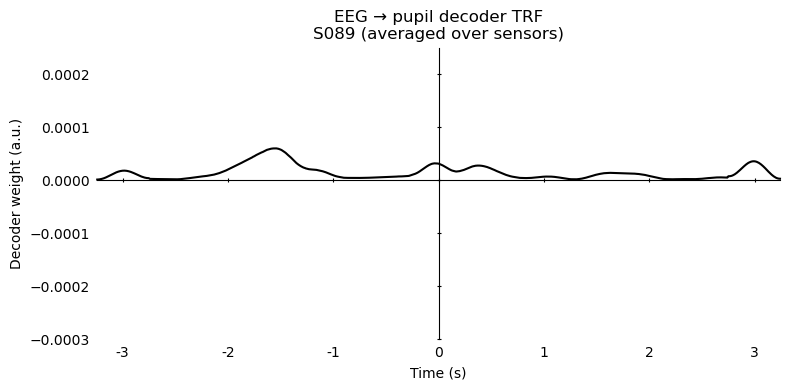

<Figure size 640x480 with 0 Axes>

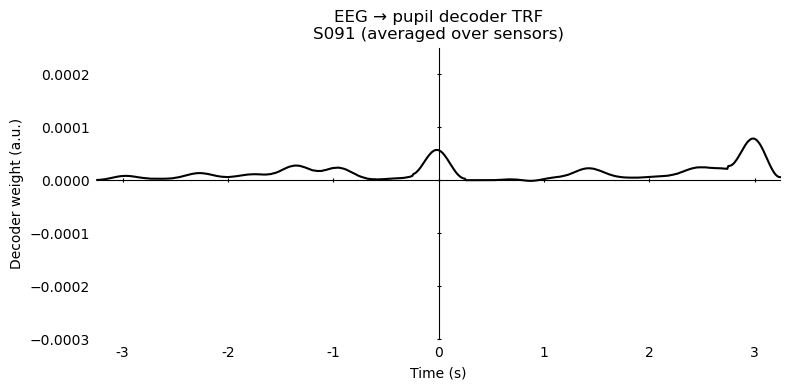

<Figure size 640x480 with 0 Axes>

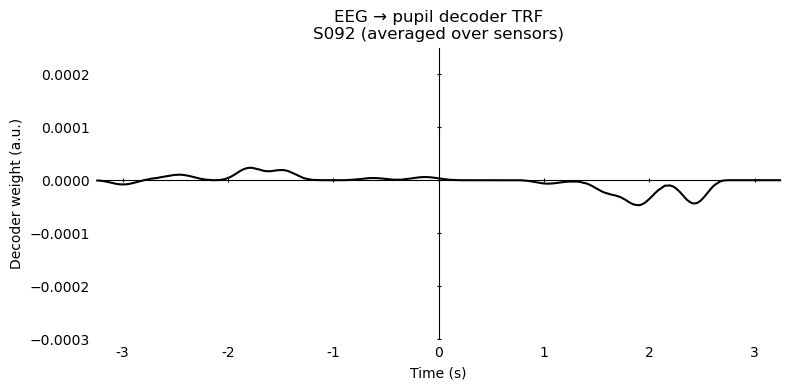

<Figure size 640x480 with 0 Axes>

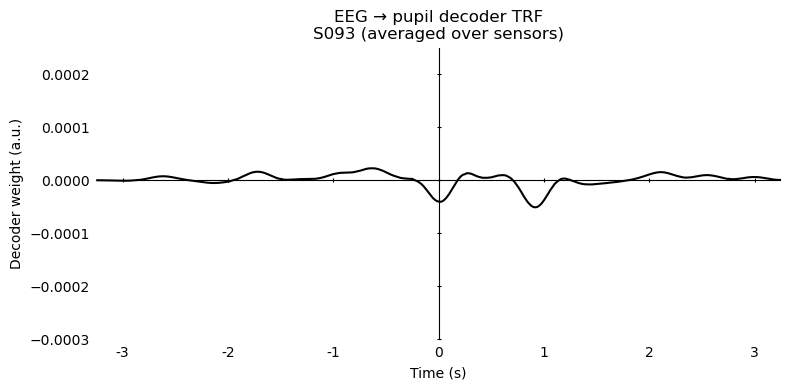

<Figure size 640x480 with 0 Axes>

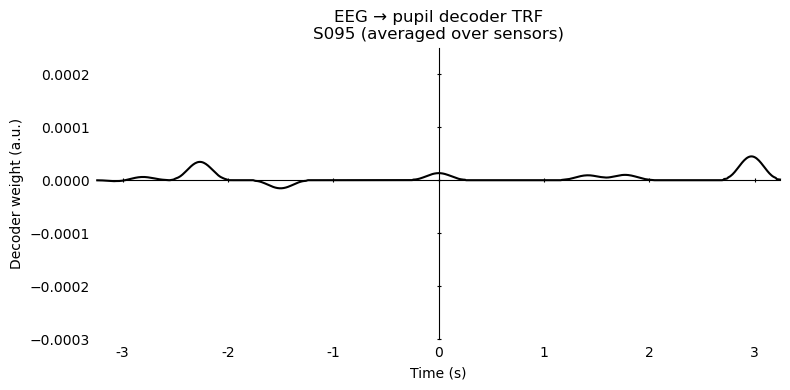

<Figure size 640x480 with 0 Axes>

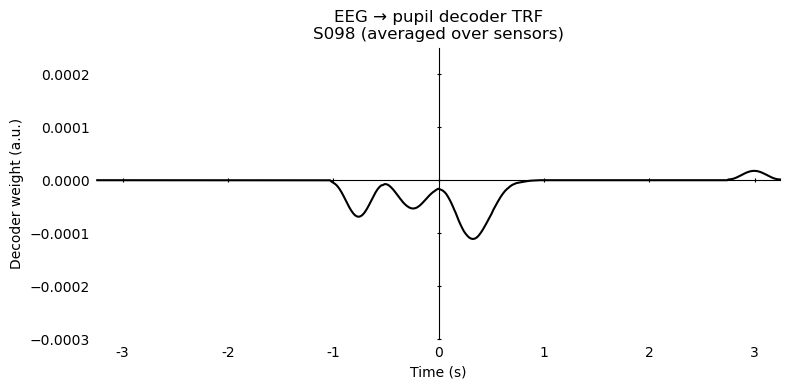

In [27]:
# trf_subj: NDVar(case × time), one TRF per subject (already computed)
trf_subj = trf_all_dec.mean('sensor')

for i, subj_label in enumerate(dataset_dec['subject']):
    plt.figure()
    eelbrain.plot.UTS(
        trf_subj[i],     # NDVar(time) for this subject
        frame='t',
        color='k',
        #linewidth=1.5,
    )
    plt.ylim(-0.0003, 0.00025)  # adjust to your scale   
    plt.title(f"EEG → pupil decoder TRF\n{str(subj_label)} (averaged over sensors)")
    plt.ylabel("Decoder weight (a.u.)")
    plt.xlabel("Time (s)")
    plt.tight_layout()
    # Optional: save instead of (or in addition to) showing
    # out_path = TRF_DIR / f"dec_TRF_{subj_label}.png"
    # plt.savefig(out_path, dpi=150)
    # plt.close()

plt.show()  # if you didn’t close figures in the loop


<Figure size 640x480 with 0 Axes>

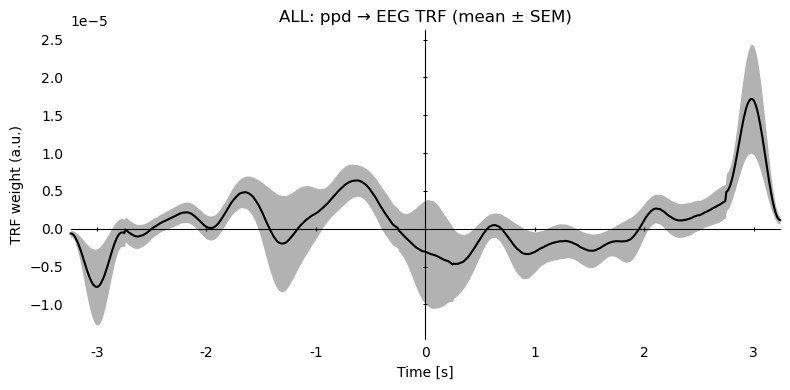

<Figure size 640x480 with 0 Axes>

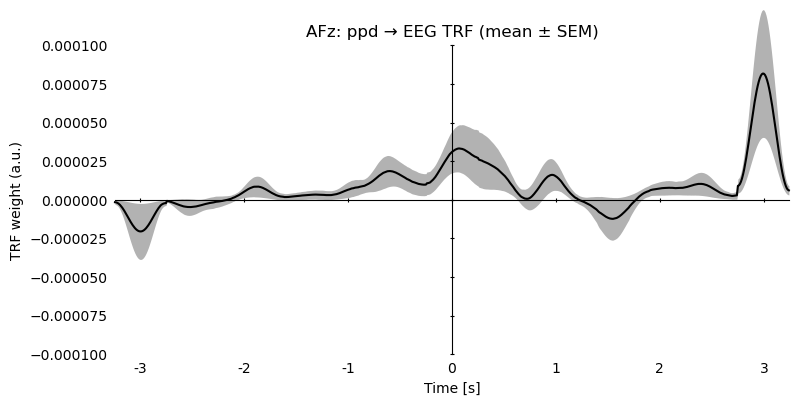

<Figure size 640x480 with 0 Axes>

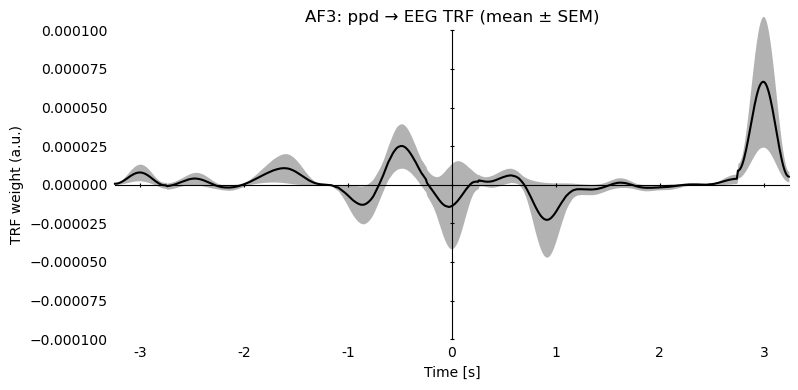

<Figure size 640x480 with 0 Axes>

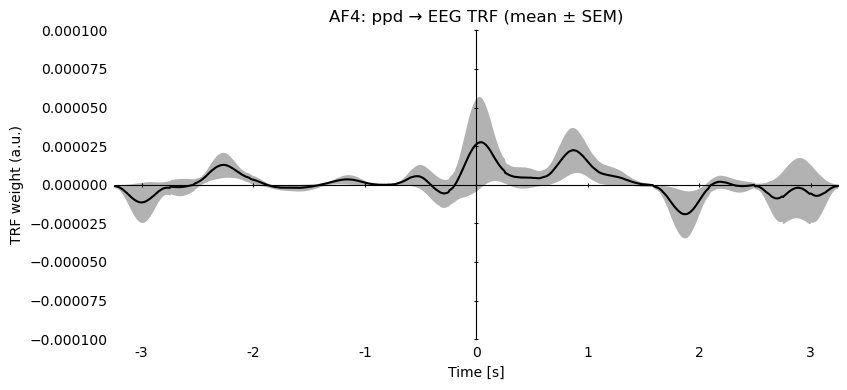

<Figure size 640x480 with 0 Axes>

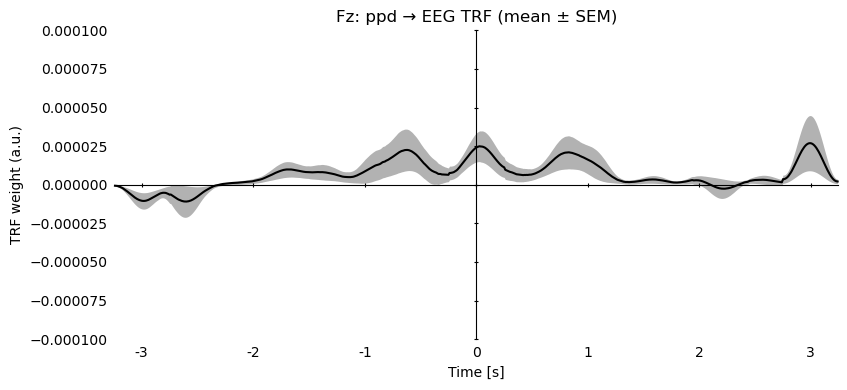

<Figure size 640x480 with 0 Axes>

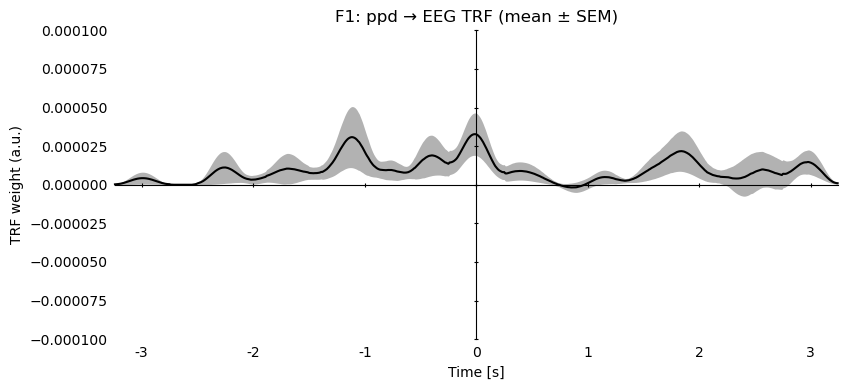

<Figure size 640x480 with 0 Axes>

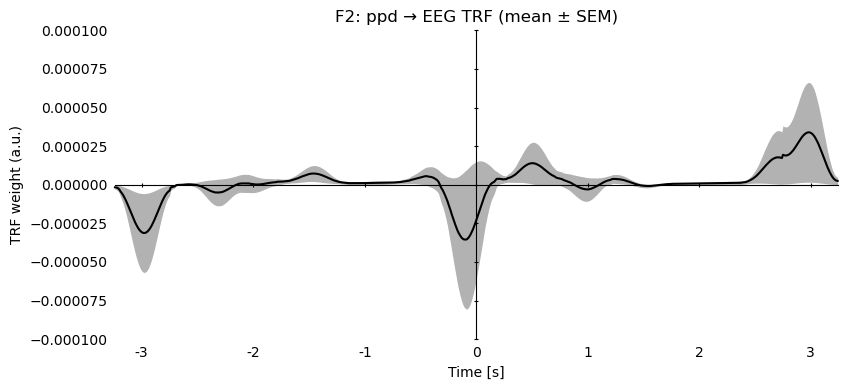

<Figure size 640x480 with 0 Axes>

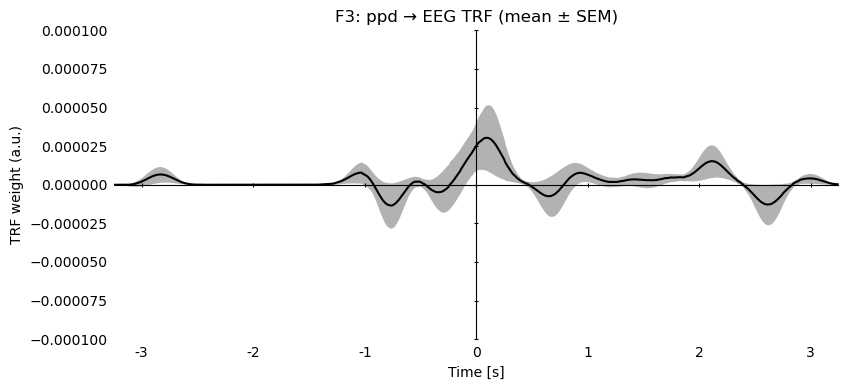

<Figure size 640x480 with 0 Axes>

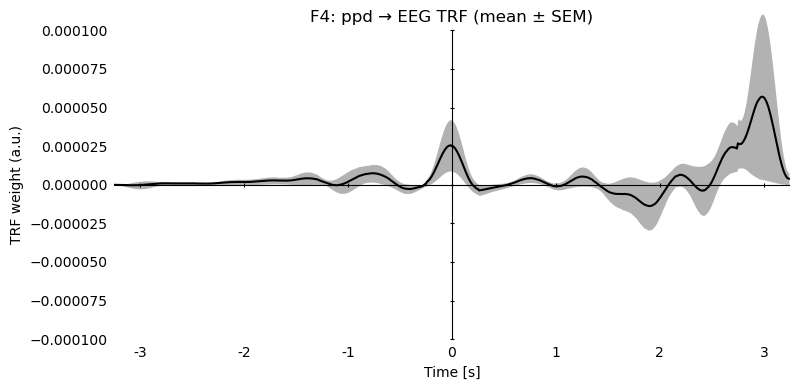

<Figure size 640x480 with 0 Axes>

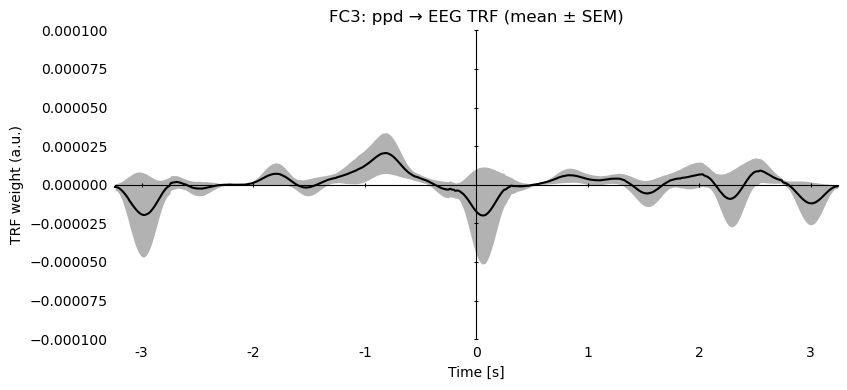

<Figure size 640x480 with 0 Axes>

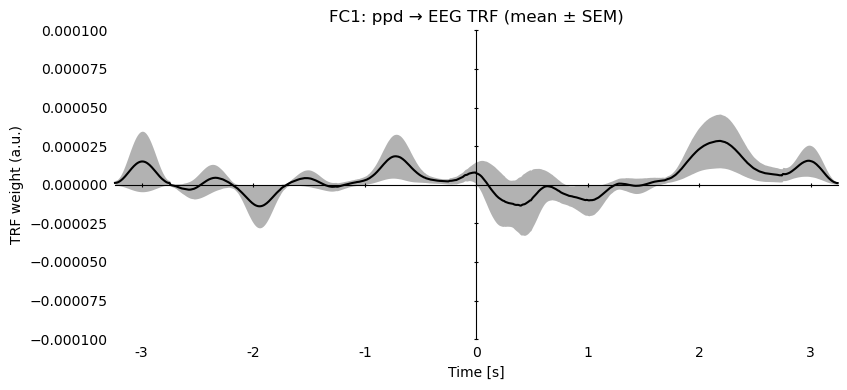

<Figure size 640x480 with 0 Axes>

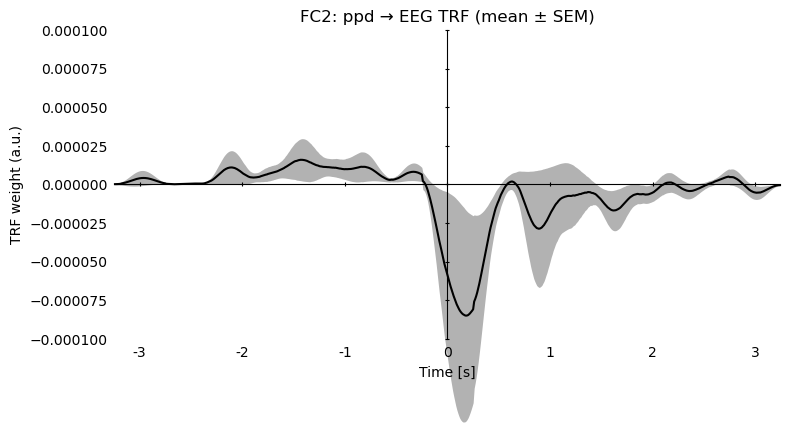

<Figure size 640x480 with 0 Axes>

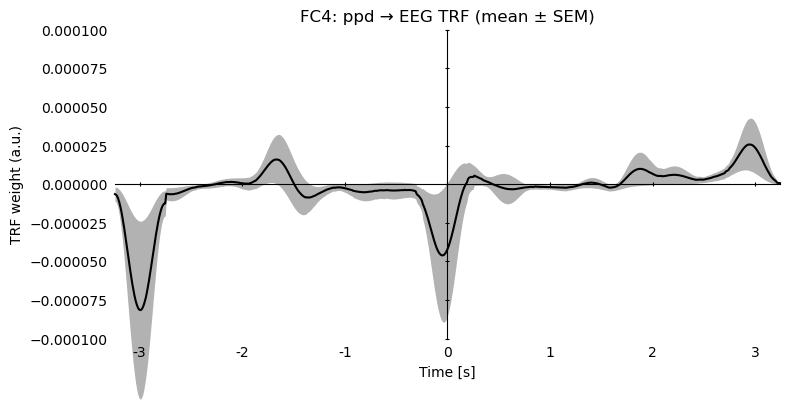

<Figure size 640x480 with 0 Axes>

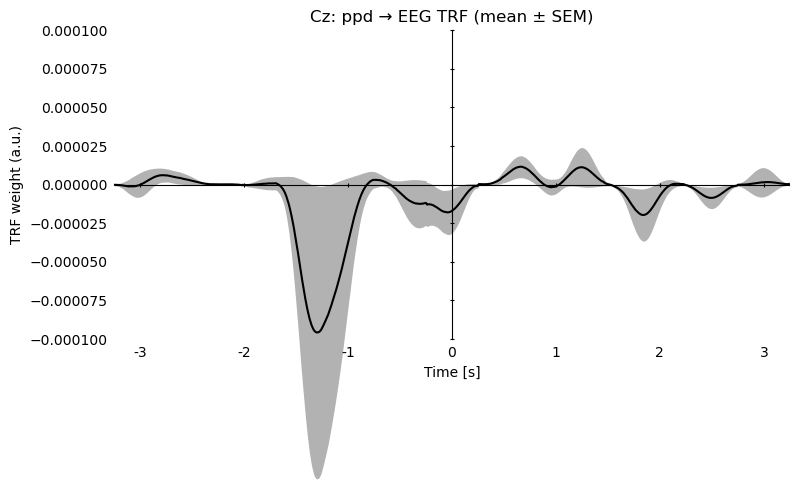

<Figure size 640x480 with 0 Axes>

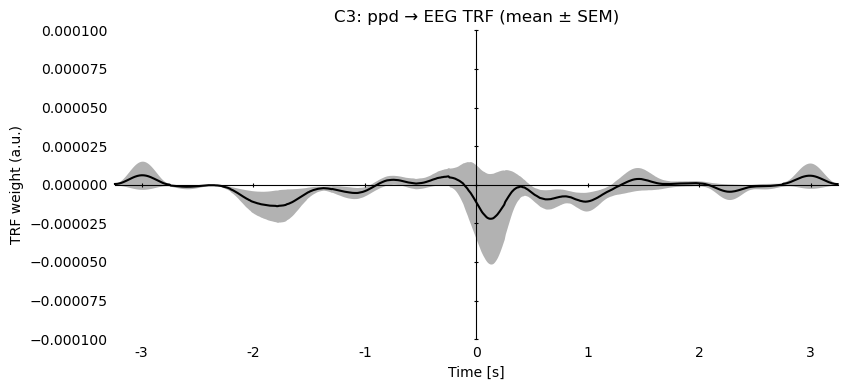

<Figure size 640x480 with 0 Axes>

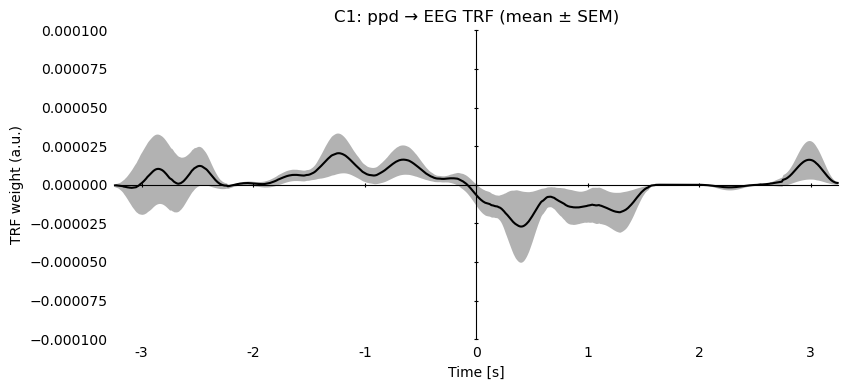

<Figure size 640x480 with 0 Axes>

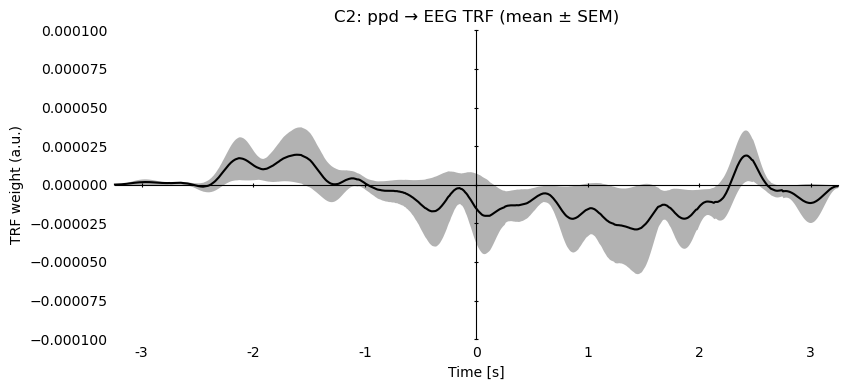

<Figure size 640x480 with 0 Axes>

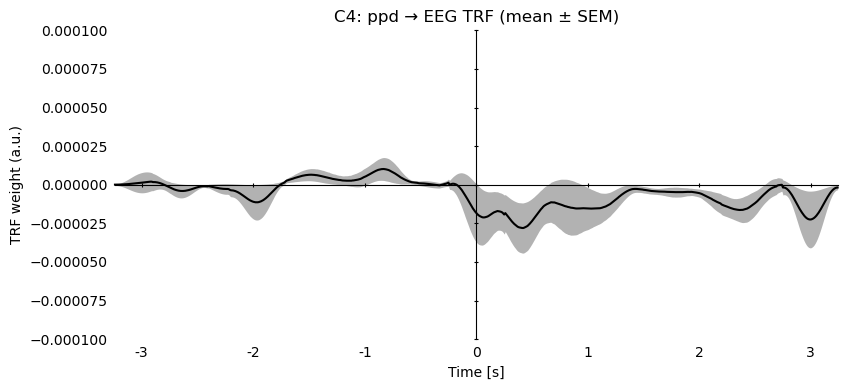

In [32]:
# trf_subj: NDVar(case × time), one TRF per subject (already computed)
trf_sensor = trf_all_dec.mean('sensor')

plt.figure()
eelbrain.plot.UTSStat(
    trf_sensor,
    error='sem',
    frame='t',
    ylabel='TRF weight (a.u.)',
    xlabel='Time [s]',
    axtitle=f"ALL: ppd → EEG TRF (mean ± SEM)",
)
plt.show()

for name in trf_all_dec.sensor:
    trf_s = trf_all_dec.sub(sensor=name)  # case × time

    plt.figure()
    eelbrain.plot.UTSStat(
        trf_s,
        error='sem',
        frame='t',
        ylabel='TRF weight (a.u.)',
        xlabel='Time [s]',
        axtitle=f"{name}: ppd → EEG TRF (mean ± SEM)",
    )
    plt.ylim(-0.0001, 0.0001)  # adjust to your scale
    plt.show()